In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Dataset .csv')

In [2]:
# first few rows and column information to understand the data structure
display(df.head())
print(df.info())

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

Based on the `df.info()` output, it looks like `Cuisines` is the relevant column for cuisine types. Let's proceed with analyzing this column.

In [3]:
# The 'Cuisines' column might contain multiple cuisines separated by commas.
# We need to split these and count each individual cuisine.

# Create a list to hold all individual cuisines
all_cuisines = []

# Iterate through each row in the 'Cuisines' column
# Handle potential NaN values by converting them to empty strings before splitting
for cuisine_list in df['Cuisines'].fillna('').apply(lambda x: x.split(', ')):
    for cuisine in cuisine_list:
        if cuisine: # Ensure we don't add empty strings as cuisines
            all_cuisines.append(cuisine.strip())

# Convert the list to a pandas Series to easily count frequencies
cuisine_series = pd.Series(all_cuisines)

# Get the top 3 most common cuisines
top_3_cuisines = cuisine_series.value_counts().head(3)

print("Top 3 Most Common Cuisines:")
display(top_3_cuisines)

Top 3 Most Common Cuisines:


,count
North Indian,3960
Chinese,2735
Fast Food,1986


In [4]:
# Calculate the percentage of restaurants that serve each of the top 3 cuisines

total_restaurants = len(df)
percentage_by_cuisine = {}

print("\nPercentage of restaurants serving each of the top cuisines:")
for cuisine_name, count in top_3_cuisines.items():

    num_restaurants_with_cuisine = df['Cuisines'].astype(str).str.contains(cuisine_name, case=False, na=False).sum()
    percentage = (num_restaurants_with_cuisine / total_restaurants) * 100
    percentage_by_cuisine[cuisine_name] = percentage
    print(f"- {cuisine_name}: {percentage:.2f}%")


Percentage of restaurants serving each of the top cuisines:
- North Indian: 41.46%
- Chinese: 28.61%
- Fast Food: 20.80%


### City Analysis: Number of Restaurants and Average Ratings

In [5]:
# 1. Identify the city with the highest number of restaurants
city_restaurant_counts = df['City'].value_counts()
highest_restaurant_city = city_restaurant_counts.idxmax()
highest_restaurant_count = city_restaurant_counts.max()

print(f"City with the highest number of restaurants: {highest_restaurant_city} ({highest_restaurant_count} restaurants)")

City with the highest number of restaurants: New Delhi (5473 restaurants)


In [6]:
# 2. Calculate the average rating for restaurants in each city
city_average_ratings = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

print("\nAverage rating for restaurants in each city (top 10):")
display(city_average_ratings.head(10))


Average rating for restaurants in each city (top 10):


,Aggregate rating
City,
Inner City,4.900000
Quezon City,4.800000
Makati City,4.650000
Pasig City,4.633333
Mandaluyong City,4.625000
Beechworth,4.600000
London,4.535000
Taguig City,4.525000
Secunderabad,4.500000


In [7]:
# 3. Determine the city with the highest average rating
highest_avg_rating_city = city_average_ratings.idxmax()
highest_avg_rating_value = city_average_ratings.max()

print(f"\nCity with the highest average rating: {highest_avg_rating_city} (Average rating: {highest_avg_rating_value:.2f})")


City with the highest average rating: Inner City (Average rating: 4.90)


### Price Range Analysis

Distribution of Price Ranges:


,count
Price range,
1,4444
2,3113
3,1408
4,586



Percentage of Restaurants in Each Price Range:


,count
Price range,
1,46.529159
2,32.593446
3,14.741912
4,6.135483


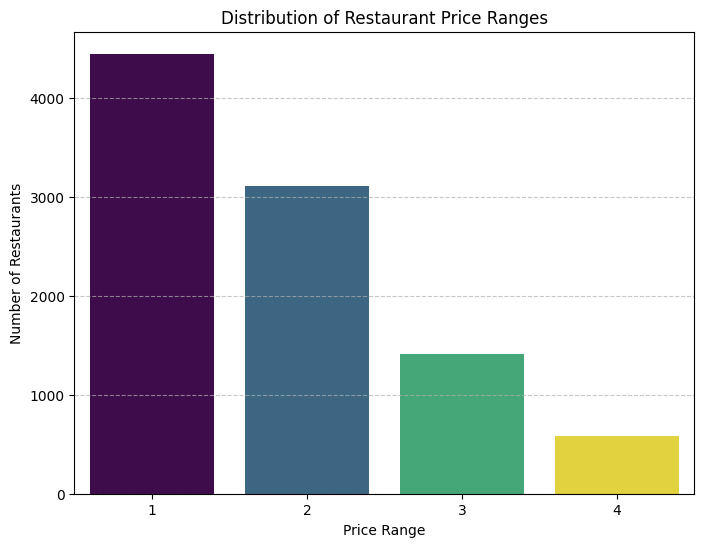

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of price ranges
price_range_counts = df['Price range'].value_counts().sort_index()

# Calculate the percentage of restaurants in each price range category
total_restaurants = len(df)
price_range_percentages = (price_range_counts / total_restaurants) * 100

print("Distribution of Price Ranges:")
display(price_range_counts)

print("\nPercentage of Restaurants in Each Price Range:")
display(price_range_percentages)

# Create a bar chart to visualize the distribution of price ranges
plt.figure(figsize=(8, 6))
sns.barplot(x=price_range_counts.index, y=price_range_counts.values, hue=price_range_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Restaurant Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=0) # Ensure price range labels are horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Online Delivery Analysis

In [10]:
# 1. Determine the percentage of restaurants that offer online delivery
# Assuming 'Yes' indicates online delivery and 'No' indicates no online delivery
online_delivery_counts = df['Has Online delivery'].value_counts()
total_restaurants = len(df)

percentage_online_delivery = (online_delivery_counts.get('Yes', 0) / total_restaurants) * 100

print(f"Percentage of restaurants offering online delivery: {percentage_online_delivery:.2f}%")

Percentage of restaurants offering online delivery: 25.66%



Average ratings by online delivery status:


,Aggregate rating
Has Online delivery,
No,2.465296
Yes,3.248837


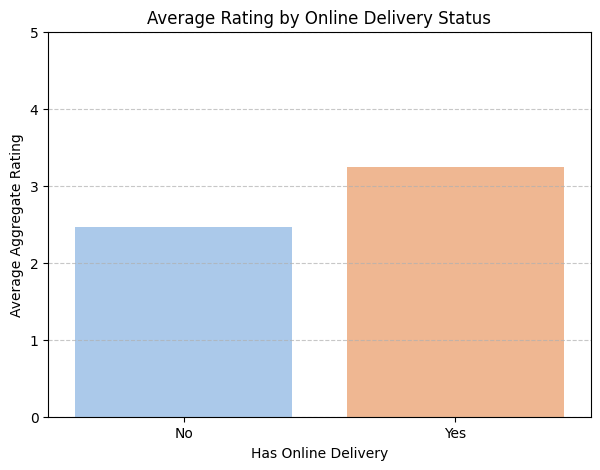

In [11]:
# 2. Compare the average ratings of restaurants with and without online delivery
average_ratings_by_online_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()

print("\nAverage ratings by online delivery status:")
display(average_ratings_by_online_delivery)

# Optional: Visualize this comparison
plt.figure(figsize=(7, 5))
sns.barplot(x=average_ratings_by_online_delivery.index, y=average_ratings_by_online_delivery.values, hue=average_ratings_by_online_delivery.index, palette='pastel', legend=False)
plt.title('Average Rating by Online Delivery Status')
plt.xlabel('Has Online Delivery')
plt.ylabel('Average Aggregate Rating')
plt.ylim(0, 5) # Ratings are typically 0-5
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()